## Online Retail - Project

### Analyze online retail transactions to uncover sales trends, customer behavior, and return patterns.

### Downloading Dataset

In [1]:
#!pip install -q pandas
#!pip install -q ucimlrepo

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo


In [4]:
print("\033[31mIn-progress...\033[0m", end="", flush=True)
online_retail = fetch_ucirepo(id=352)
df = online_retail.data.original
# Original Path: https://archive.ics.uci.edu/dataset/352/online+retail
print("\r\033[32mStatus: Completed\033[0m")

Status: Completed


### Data Wrangling

In [5]:
# Custom function to inspect the data
import DataClean

In [6]:
DataClean.inspect_data(df)

 Rows: 541,909
 Columns: 8



  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom   



       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899     CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254    CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255  CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138    BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID Country  
541904  12/9/2011 12:50       0.85     12680.0  France  
541905  12/9/2011 12:50       2.10     12680.0  France  
541906  12/9/2011 12:50       4.15     12680.0  France  
541907  12/9/2011 12:50       4.15     12680.0  France  
541908  12/9/2011 12:50       4.95     12680.0  France   



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None 



            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000 



      InvoiceNo  count
0        573585   1114
1        581219    749
2        581492    731
3        580729    721
4        558475    705
...         ...    ...
25895    581483      1
25896    581566      1
25897   C581499      1
25898   C536383      1
25899   C536379      1

[25900 rows x 2 columns]


     StockCode  count
0       85123A   2313
1        22423   2203
2       85099B   2159
3        47566   1727
4        20725   1639
...        ...    ...
4065    85179a      1
4066     23617      1
4067    90214U      1
4068    47591b      1
4069    72802c      1

[4070 rows x 2 columns]


                             Description  count
0     WHITE HANGING HEART T-LIGHT HOLDER   2369
1               REGENCY CAKESTAND 3 TIER   2200
2                JUMBO BAG RED RETROSPOT   2159
3                          PARTY BUNTING   1727
4                LUNCH BAG RED RETROSPOT   1638
...                                  ...    ...
4219                       dotcom adjust      1
4220         LARGE HE

             Missing_Count  Missing_Percentage (%)
InvoiceNo                0                    0.00
StockCode                0                    0.00
Description           1454                    0.27
Quantity                 0                    0.00
InvoiceDate              0                    0.00
UnitPrice                0                    0.00
CustomerID          135080                   24.93
Country                  0                    0.00 



             Missing_Count  Missing_Percentage (%)
Description           1454                    0.27
CustomerID          135080                   24.93 



5268 



### Inspect Anomalies Entries in the field

In [7]:
DataClean.inspect_anomalies(df)

🔎 Suspicious (string sort) - Ascending:
0    536365
1    536365
2    536365
3    536365
4    536365
Name: InvoiceNo, dtype: object 

🔎 Suspicious (string sort) - Decending:
541717    C581569
541716    C581569
541715    C581568
541541    C581499
540448    C581490
Name: InvoiceNo, dtype: object 

📃 Actual (typed sort) - Ascending
0    536365
1    536365
2    536365
3    536365
4    536365
Name: InvoiceNo, dtype: object 

📃 Actual (typed sort) - Decending
541717    C581569
541716    C581569
541715    C581568
541541    C581499
540448    C581490
Name: InvoiceNo, dtype: object 



🔎 Suspicious (string sort) - Ascending:
160128    10002
6166      10002
75792     10002
63082     10002
76571     10002
Name: StockCode, dtype: object 

🔎 Suspicious (string sort) - Decending:
40383                m
178556    gift_0001_50
245516    gift_0001_50
239744    gift_0001_50
42057     gift_0001_50
Name: StockCode, dtype: object 

📃 Actual (typed sort) - Ascending
160128    10002
6166      10002
75792     10002
63082     10002
76571     10002
Name: StockCode, dtype: object 

📃 Actual (typed sort) - Decending
40383                m
178556    gift_0001_50
245516    gift_0001_50
239744    gift_0001_50
42057     gift_0001_50
Name: StockCode, dtype: object 



🔎 Suspicious (string sort) - Ascending:
202872     4 PURPLE FLOCK DINNER CANDLES
488534     4 PURPLE FLOCK DINNER CANDLES
257041     4 PURPLE FLOCK DINNER CANDLES
257012     4 PURPLE FLOCK DINNER CANDLES
325007     4 PURPLE FLOCK DINNER CANDLES
Name: Description, dtype: object 

🔎 Suspicious (string sort) - Decending:
114538               wrongly sold sets
114522            wrongly sold as sets
117895    wrongly sold (22719) barcode
263884    wrongly marked. 23343 in box
456831     wrongly marked carton 22804
Name: Description, dtype: object 

📃 Actual (typed sort) - Ascending
1057       4 PURPLE FLOCK DINNER CANDLES
499041     4 PURPLE FLOCK DINNER CANDLES
344989     4 PURPLE FLOCK DINNER CANDLES
160509     4 PURPLE FLOCK DINNER CANDLES
399063     4 PURPLE FLOCK DINNER CANDLES
Name: Description, dtype: object 

📃 Actual (typed sort) - Decending
114538               wrongly sold sets
114522            wrongly sold as sets
117895    wrongly sold (22719) barcode
263884    wrongly marked.

🔎 Suspicious (string sort) - Ascending:
378637    -1
331040    -1
313892    -1
313893    -1
331036    -1
Name: Quantity, dtype: object 

🔎 Suspicious (string sort) - Decending:
437471    992
467793     99
15788      99
209637     98
537362     98
Name: Quantity, dtype: object 

📃 Actual (typed sort) - Ascending
540422   -80995
61624    -74215
225529    -9600
225530    -9600
4287      -9360
Name: Quantity, dtype: int64 

📃 Actual (typed sort) - Decending
540421    80995
61619     74215
502122    12540
74614      5568
421632     4800
Name: Quantity, dtype: int64 



🔎 Suspicious (string sort) - Ascending:
50806    1/10/2011 10:04
50807    1/10/2011 10:07
50808    1/10/2011 10:08
50828    1/10/2011 10:32
50815    1/10/2011 10:32
Name: InvoiceDate, dtype: object 

🔎 Suspicious (string sort) - Decending:
332571    9/9/2011 9:52
332544    9/9/2011 9:52
332551    9/9/2011 9:52
332550    9/9/2011 9:52
332549    9/9/2011 9:52
Name: InvoiceDate, dtype: object 

📃 Actual (typed sort) - Ascending
50806    1/10/2011 10:04
50807    1/10/2011 10:07
50808    1/10/2011 10:08
50828    1/10/2011 10:32
50815    1/10/2011 10:32
Name: InvoiceDate, dtype: object 

📃 Actual (typed sort) - Decending
332571    9/9/2011 9:52
332544    9/9/2011 9:52
332551    9/9/2011 9:52
332550    9/9/2011 9:52
332549    9/9/2011 9:52
Name: InvoiceDate, dtype: object 



🔎 Suspicious (string sort) - Ascending:
299983    -11062.06
299984    -11062.06
41491           0.0
200595          0.0
20392           0.0
Name: UnitPrice, dtype: object 

🔎 Suspicious (string sort) - Decending:
194027     99.96
256883     99.96
515835     988.0
508561    987.14
431565     98.79
Name: UnitPrice, dtype: object 

📃 Actual (typed sort) - Ascending
299983   -11062.06
299984   -11062.06
204602        0.00
387137        0.00
387138        0.00
Name: UnitPrice, dtype: float64 

📃 Actual (typed sort) - Decending
222681    38970.00
524602    17836.46
43702     16888.02
43703     16453.71
16356     13541.33
Name: UnitPrice, dtype: float64 



🔎 Suspicious (string sort) - Ascending:
61624     12346.0
61619     12346.0
148289    12347.0
535009    12347.0
535008    12347.0
Name: CustomerID, dtype: object 

🔎 Suspicious (string sort) - Decending:
239698    nan
295855    nan
295849    nan
295850    nan
295851    nan
Name: CustomerID, dtype: object 

📃 Actual (typed sort) - Ascending
61624     12346.0
61619     12346.0
148292    12347.0
148291    12347.0
535009    12347.0
Name: CustomerID, dtype: float64 

📃 Actual (typed sort) - Decending
392748    18287.0
392749    18287.0
392744    18287.0
392745    18287.0
392746    18287.0
Name: CustomerID, dtype: float64 



🔎 Suspicious (string sort) - Ascending:
344571    Australia
270069    Australia
270070    Australia
270071    Australia
270072    Australia
Name: Country, dtype: object 

🔎 Suspicious (string sort) - Decending:
471672    Unspecified
323439    Unspecified
471669    Unspecified
471668    Unspecified
471667    Unspecified
Name: Country, dtype: object 

📃 Actual (typed sort) - Ascending
344571    Australia
270069    Australia
270070    Australia
270071    Australia
270072    Australia
Name: Country, dtype: object 

📃 Actual (typed sort) - Decending
471672    Unspecified
323439    Unspecified
471669    Unspecified
471668    Unspecified
471667    Unspecified
Name: Country, dtype: object 



### Removing Duplicates

In [8]:
df[df.duplicated(keep=False)].sort_values(list(df.columns))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,11/4/2011 13:25,2.95,15110.0,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
529980,C580764,22667,RECIPE BOX RETROSPOT,-12,12/6/2011 10:38,2.95,14562.0,United Kingdom


In [9]:
df.drop_duplicates(keep='last', inplace=True)

In [10]:
df.shape

(536641, 8)

##### Note: The record count was 541,909 and removed 5,268, hence the current total records are 536,641

#### Column name clean-up

In [11]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')

In [12]:
df.rename(columns={'invoicedate':'invoice_datetime'}, inplace = True)

#### Fill blanks with NaN

In [13]:
df.replace("?",np.nan, inplace=True)

### Fixing the data types

In [14]:
df.dtypes

invoiceno            object
stockcode            object
description          object
quantity              int64
invoice_datetime     object
unitprice           float64
customerid          float64
country              object
dtype: object

##### *Assigning DateTime for InvoiceDate and Integer for CustomerID*
##### *Creating new columns Invoice_Date, Invoice_Time*

In [15]:
df['invoice_datetime'] = pd.to_datetime(df['invoice_datetime'], errors='coerce')
df['customerid'] = df['customerid'].astype('Int64')

In [16]:
df.dtypes

invoiceno                   object
stockcode                   object
description                 object
quantity                     int64
invoice_datetime    datetime64[ns]
unitprice                  float64
customerid                   Int64
country                     object
dtype: object

#### Checking outlier values at a glance

In [17]:
df.loc[df['quantity']==80995]

,invoiceno,stockcode,description,quantity,invoice_datetime,unitprice,customerid,country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom


In [18]:
df.loc[df['description']=='PAPER CRAFT , LITTLE BIRDIE']

,invoiceno,stockcode,description,quantity,invoice_datetime,unitprice,customerid,country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom


In [19]:
df.loc[df['quantity']==1404]

,invoiceno,stockcode,description,quantity,invoice_datetime,unitprice,customerid,country
533812,581115,22413,METAL SIGN TAKE IT OR LEAVE IT,1404,2011-12-07 12:20:00,2.75,15195,United Kingdom


In [20]:
df.loc[(df['description'].str.contains('METAL SIGN TAKE IT OR LEAVE IT', case=False, na=False)) & (df['quantity']>100)]

,invoiceno,stockcode,description,quantity,invoice_datetime,unitprice,customerid,country
264113,560080,22413,METAL SIGN TAKE IT OR LEAVE IT,192,2011-07-14 16:23:00,3.20,17450,United Kingdom
285372,561901,22413,METAL SIGN TAKE IT OR LEAVE IT,240,2011-07-31 15:42:00,2.95,14156,EIRE
533812,581115,22413,METAL SIGN TAKE IT OR LEAVE IT,1404,2011-12-07 12:20:00,2.75,15195,United Kingdom


#### Separate datasets as Sales and Returns

In [21]:
print("\033[31mIn-progress...\033[0m", end="", flush=True)

df['invoice_datetime'] = pd.to_datetime(df['invoice_datetime'])

#Identify returns
df['is_return'] = ((df['quantity'] < 0) | (df['invoiceno'].astype(str).str.startswith('C')))

# Split data
sales = df[df['quantity'] > 0].copy()
returns = df[df['is_return']].copy()

sales = sales.reset_index().rename(columns={'index': 'sales_id'})
returns = returns.reset_index().rename(columns={'index': 'return_id'})

#Normalize quantity
sales['quantity_abs'] = sales['quantity']
returns['quantity_abs'] = returns['quantity'].abs()

sales = sales.rename(columns={'invoice_datetime': 'invoice_datetime_sale'})
returns = returns.rename(columns={'invoice_datetime': 'invoice_datetime_return'})


#Merge
matches = sales.merge(returns, on=['customerid', 'stockcode', 'unitprice', 'quantity_abs'], how='inner')

#Apply 30-day window
matches = matches[
    (matches['invoice_datetime_return'] >= matches['invoice_datetime_sale']) &
    (matches['invoice_datetime_return'] <= matches['invoice_datetime_sale'] + pd.Timedelta(days=30))]

#FIFO Matching
matches = matches.sort_values(by=['customerid', 'stockcode', 'invoice_datetime_sale'])

matches['rank'] = matches.groupby(['return_id'])['invoice_datetime_sale'].rank(method='first')

matches = matches[matches['rank'] == 1]


#Flag results
df['is_cancelled_pair'] = False

df.loc[df.index.isin(matches['sales_id']), 'is_cancelled_pair'] = True
df.loc[df.index.isin(matches['return_id']), 'is_cancelled_pair'] = True

print("\r\033[32mStatus: Completed\033[0m")

Status: Completed


In [22]:
df.dtypes

invoiceno                    object
stockcode                    object
description                  object
quantity                      int64
invoice_datetime     datetime64[ns]
unitprice                   float64
customerid                    Int64
country                      object
is_return                      bool
is_cancelled_pair              bool
dtype: object

In [23]:
#sales_df = df[(df['quantity'] > 0) & (~df['is_cancelled_pair'])].copy()
#sales_df = sales_df.drop(columns=['is_return', 'is_cancelled_pair'])
sales_df = df.copy()

In [24]:
returns_df = df[(df['is_cancelled_pair'])].copy()

#### Feature Engineering

In [25]:
sales_df['revenue'] = sales_df['quantity'] * sales_df['unitprice']

sales_df['year'] = sales_df['invoice_datetime'].dt.year
sales_df['month'] = sales_df['invoice_datetime'].dt.month
sales_df['day'] = sales_df['invoice_datetime'].dt.day
sales_df['hour'] = sales_df['invoice_datetime'].dt.hour
sales_df['dayofweek'] = sales_df['invoice_datetime'].dt.day_name()


#### Normalize Country Names

In [26]:
sorted(sales_df['country'].unique())

['Australia',
 'Austria',
 'Bahrain',
 'Belgium',
 'Brazil',
 'Canada',
 'Channel Islands',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'EIRE',
 'European Community',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hong Kong',
 'Iceland',
 'Israel',
 'Italy',
 'Japan',
 'Lebanon',
 'Lithuania',
 'Malta',
 'Netherlands',
 'Norway',
 'Poland',
 'Portugal',
 'RSA',
 'Saudi Arabia',
 'Singapore',
 'Spain',
 'Sweden',
 'Switzerland',
 'USA',
 'United Arab Emirates',
 'United Kingdom',
 'Unspecified']

In [27]:
sales_df['country'] = sales_df['country'].replace(
    {'EIRE': 'Ireland',
    'USA': 'United States',
    'RSA': 'South Africa'})

In [28]:
sales_df['country'] = sales_df['country'].str.strip().str.title()

## Exporting clean copy to CSV

In [ ]:
sales_df.to_csv("Online_Retail_Dataset.csv", index = False)
print("Data exported into 'Online_Retail_Dataset.csv'")

In [ ]:
sales_df.head().to_csv("Online_Retail_Dataset_5_rows.csv", index = False)

## Export to SQL

In [31]:
!pip install -q sqlalchemy
!pip install pyodbc

In [32]:
import sqlalchemy as sal
import warnings
from sqlalchemy.exc import SAWarning

Note: Dropping revenue column as we can create calculated column in SQL

In [33]:
sql_df = sales_df.drop(columns=['revenue']).copy()

In [34]:
print("\033[31mIn-progress...\033[0m", end="", flush=True)

warnings.filterwarnings("ignore", category=SAWarning)

engine = sal.create_engine('mssql+pyodbc://@DESKTOP-C4SCQF3\\SQLEXPRESS/retail_dw?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes')
conn = engine.connect()


print("\r\033[32mStatus: Connected\033[0m")

Status: Connected


In [ ]:
print("\033[31mIn-progress...\033[0m", end="", flush=True)

sql_df.to_sql('otransactions', con=engine, index = False, if_exists = 'append')

print("\r\033[32mStatus: Exported to SQL\033[0m")

In [36]:
pd.read_sql("SELECT TOP 5 * FROM otransactions", conn)

,transaction_id,invoiceno,stockcode,description,quantity,invoice_datetime,unitprice,customerid,country,is_return,is_cancelled_pair,revenue,year,month,day,hour,dayofweek
0,15569,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,15.30,2010,12,1,8,Wednesday
1,15570,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,2010,12,1,8,Wednesday
2,15571,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False,22.00,2010,12,1,8,Wednesday
3,15572,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,2010,12,1,8,Wednesday
4,15573,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,2010,12,1,8,Wednesday


## Exploratory Data Analysis

#### Sales Trend Over Time

<Axes: xlabel='month'>

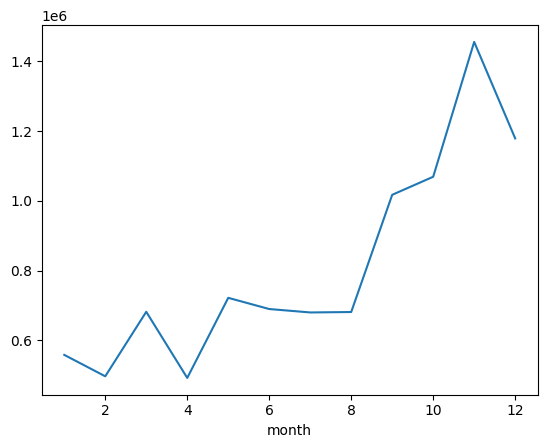

In [37]:
sales_df.groupby('month')['revenue'].sum().plot()

Insight: The peak months are November and December, and the reason could be the festival time.

#### Sales by Hour

<Axes: xlabel='hour'>

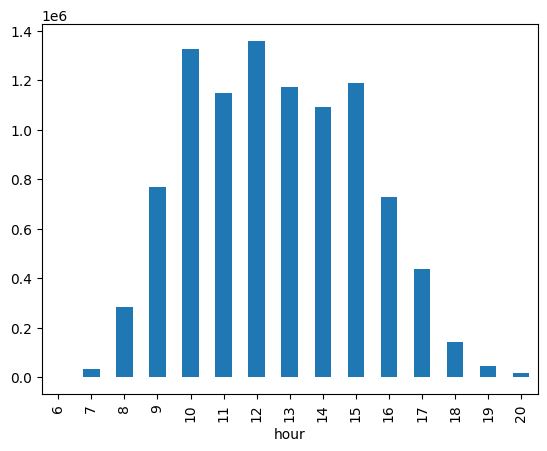

In [38]:
sales_df.groupby('hour')['revenue'].sum().plot(kind='bar')

Insight: The peak shopping hours are between 10:00 AM and 3:00 PM, and the 12:00 PM is the most peak hour.

#### Sales by Country - Top 10

<Axes: xlabel='country'>

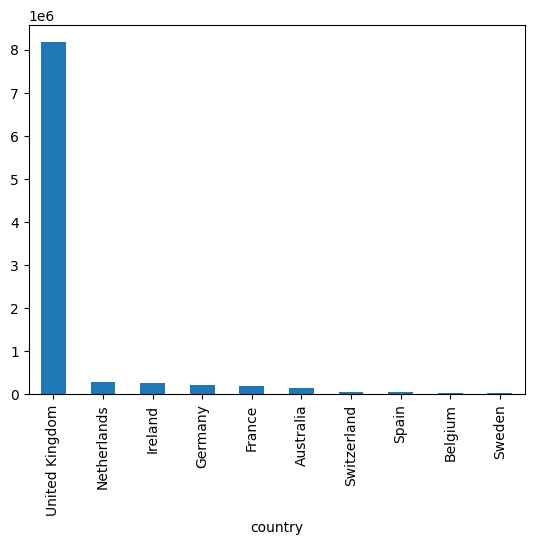

In [39]:
sales_df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

Insight: UK is the top country in online purchase

#### Top 10 Selling Products

In [40]:
sales_df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35298
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: quantity, dtype: int64

#### Top Customers

In [41]:
sales_df.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)

customerid
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: revenue, dtype: float64

#### Return Analysis

In [42]:
returns_df.shape

(4440, 10)

In [43]:
returns_df.groupby('description')['quantity'].sum().sort_values().head(10)

description
reverse previous adjustment        -1300
re dotcom quick fix.                -100
WOODEN FRAME ANTIQUE WHITE           -48
PAPER CHAIN KIT 50'S CHRISTMAS       -40
SET 2 TEA TOWELS I LOVE LONDON       -12
SMALL HEART MEASURING SPOONS         -12
VINTAGE RED TRIM ENAMEL BOWL         -12
BLUE/CREAM STRIPE CUSHION COVER      -12
OVEN MITT APPLES DESIGN              -10
BREAD BIN DINER STYLE IVORY           -8
Name: quantity, dtype: int64

#### Return Rate

In [44]:
return_rate = (len(returns_df) / len(df)) * 100
print(f"{return_rate:.2f}%")

0.83%


#### RFM Analysis

In [46]:
#Keep only valid sales
rfm_df = sales_df[(sales_df['quantity'] > 0) & (sales_df['unitprice'] > 0)].copy()

# Create Revenue
rfm_df['revenue'] = rfm_df['quantity'] * rfm_df['unitprice']

snapshot_date = rfm_df['invoice_datetime'].max() + pd.Timedelta(days=1)

In [47]:
#Creating RFM Table
rfm = rfm_df.groupby('customerid').agg({
    'invoice_datetime': lambda x: (snapshot_date - x.max()).days,
    'invoiceno': 'count',                                     
    'revenue': 'sum'})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [48]:
#RFM Score
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [49]:
#Combine Scores
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str))

In [50]:
rfm['Segment'] = 'Others'

rfm.loc[rfm['RFM_Score'] == '555', 'Segment'] = 'Champions'
rfm.loc[(rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 4), 'Segment'] = 'Loyal Customers'
rfm.loc[(rfm['R_Score'] >= 4), 'Segment'] = 'Recent Customers'
rfm.loc[(rfm['R_Score'] <= 2) & (rfm['F_Score'] <= 2), 'Segment'] = 'Lost Customers'

In [51]:
rfm['Segment'].value_counts()

Segment
Recent Customers    2498
Lost Customers      1100
Others               431
Champions            309
Name: count, dtype: int64

<Axes: xlabel='Segment'>

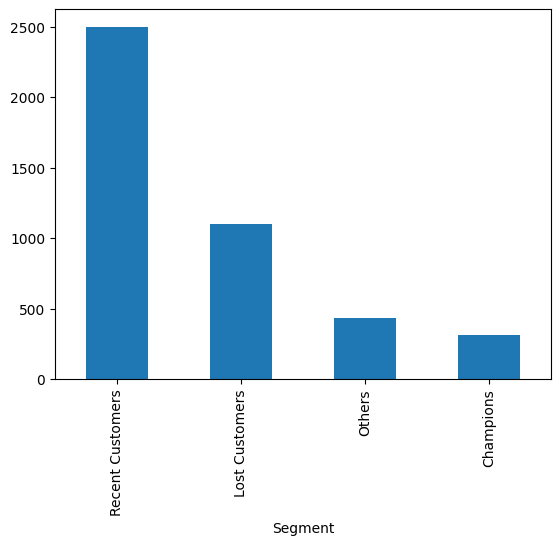

In [52]:
rfm['Segment'].value_counts().plot(kind='bar')